## LangGraph basics.

We will build a simple Graph using `langgraph`. 
We will have 4 nodes: **start_play**, then we have to decide **football** or **tennis** and then we have **end** node.
We will **NOT** use any kind of LLMs in this example.

##### Components of Langgraph:

1. Nodes - in context of LangGraph **Nodes** are **simple Python functions**, which are performing some task.

2. Edges - Connect the Nodes. We also have **Conditional Edges**.

3. State - State schema serves as the input for Nodes and Edges 

4. StateGraph - Structure of the entire graph

#### Building the graph
First, we will define the **State** of the graph. The state schema serves as the input schema for all Nodes and Edges in the Graph.

Let's use the TypedDict class from Python's typing module as our schema, which provides type hints for the keys. 

In [2]:
from typing_extensions import TypedDict

class State(TypedDict):
    graph_info: str

## Nodes

Nodes are just **Python functions**. The first positional argument is the State.

Because the State is a TypedDict with schema as defined above, each node can access the key 'graph_info'.
Each Node returns a new value of the state key graph state. 

By default, the new value returned by each node will override the prior state value. 

In [3]:
# First node
def start_play(state: State):
    print('Start_Play node has been called')
    return {'graph_info': state['graph_info'] + 'I am planning to play '}

# Second node
def football(state: State):
    print('Football node has been called')
    return {'graph_info': state['graph_info'] + 'Football'}

# Third node
def tennis(state: State):
    print('Tennis node has been called')
    return {'graph_info': state['graph_info'] + 'Tennis'}

In [4]:
import random
from typing import Literal # It represents a Constant

def random_play(state: State) -> Literal['football', 'tennis']:
    graph_info = state['graph_info']

    if random.randint(0, 1) > .5:
        return 'football'
    return 'tennis' 

#### Graph Construction

Now we need to build the graph from the components we created above.
The `StateGraph` class is the graph class that we will use. 

1. Initialize the StateGraph with the State class
2. Add Nodes and Edges
3. Use a START Node, a special Node that sends the user input to the graph, to indicate where to start our graph
4. Define END Node, a special Node that represents a Terminal Node
5. Compile the graph to perform a few basic checks on the graph structure
6. Visualize the graph in **Mermaid diagram**

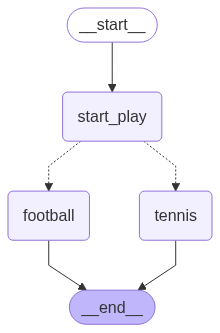

In [5]:
from IPython.display import Image, display # To display the graph

from langgraph.graph import StateGraph, START, END

# Build the graph
graph = StateGraph(state_schema=State)

# Add the nodes
graph.add_node(node="start_play", action=start_play)
graph.add_node(node="football", action=football)
graph.add_node(node="tennis", action=tennis)

# Schedule the flow of the graph
graph.add_edge(start_key=START, end_key='start_play')
graph.add_conditional_edges('start_play', random_play)
graph.add_edge('football', END)
graph.add_edge('tennis', END)

# Compile the graph
graph_builder = graph.compile()

# Visualize the graph
display(Image(graph_builder.get_graph().draw_mermaid_png()))

#### Graph Invocation 

In [10]:
state: State = { 'graph_info': 'My name is Dimo. ' }
graph_builder.invoke(state)

Start_Play node has been called
Tennis node has been called


{'graph_info': 'My name is Dimo. I am planning to play Tennis'}